In [ ]:
# Import all necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.preprocessing import PolynomialFeatures
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, AdaBoostRegressor
import xgboost as xgb
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import make_pipeline
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# Load the main dataset
df1 = pd.read_csv('ML case Study.csv')

In [ ]:
# Displaying the first five rows of the dataset
df1.head()

,College,City,Role,Previous CTC,Previous job change,Graduation Marks,EXP (Month),CTC
0,SVNIT Surat,Asansol,Manager,55523.0,3,66,19,71406.58
1,NIT Bhopal,Ajmer,Executive,57081.0,1,84,18,68005.87
2,"IEM, Kolkata",Rajpur Sonarpur,Executive,60347.0,2,52,28,76764.02
3,"KIIT, Bhubaneswar",Ajmer,Executive,49010.0,2,81,33,82092.39
4,DTU,Durgapur,Executive,57879.0,4,74,32,73878.10


In [ ]:
# Displaying the shape of the dataset to understand its dimensionality
df1.shape

(1589, 8)

In [ ]:
# Displaying information about the dataframe df1
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1589 entries, 0 to 1588
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   College              1589 non-null   object 
 1   City                 1589 non-null   object 
 2   Role                 1589 non-null   object 
 3   Previous CTC         1589 non-null   float64
 4   Previous job change  1589 non-null   int64  
 5   Graduation Marks     1589 non-null   int64  
 6   EXP (Month)          1589 non-null   int64  
 7   CTC                  1589 non-null   float64
dtypes: float64(2), int64(3), object(3)
memory usage: 99.4+ KB


In [ ]:
df1.describe()

,Previous CTC,Previous job change,Graduation Marks,EXP (Month),CTC
count,1589.000000,1589.000000,1589.000000,1589.000000,1589.000000
mean,55518.453744,2.528634,59.855255,39.044682,75353.278798
std,6655.218445,1.123918,14.935139,14.108875,12587.288237
min,36990.000000,1.000000,35.000000,18.000000,53020.320000
25%,50518.000000,2.000000,46.000000,26.000000,66902.350000
50%,55291.000000,3.000000,60.000000,39.000000,73028.670000
75%,60109.000000,4.000000,73.000000,51.000000,80588.670000
max,77911.000000,4.000000,85.000000,64.000000,123416.990000


In [ ]:
# Listing all column names to understand the features
df1.columns

Index(['College', 'City', 'Role', 'Previous CTC', 'Previous job change',
       'Graduation Marks', 'EXP (Month)', 'CTC'],
      dtype='object')

In [ ]:
# Checking for any missing or null values in the dataset
df1.isnull().sum()

College                0
City                   0
Role                   0
Previous CTC           0
Previous job change    0
Graduation Marks       0
EXP (Month)            0
CTC                    0
dtype: int64

In [ ]:
# Loading additional data from colleges csv file
df2 = pd.read_csv('Colleges.csv')

In [ ]:
df2.head()

,Tier 1,Tier 2,Tier 3
0,IIT Bombay,IIIT Bangalore,"Ramaiah Institute of Technology, Bengaluru"
1,IIT Delhi,IIIT Delhi,TIET/Thapar University
2,IIT Kharagpur,IGDTUW,Manipal Main Campus
3,IIT Madras,NIT Calicut,VIT Vellore
4,IIT Kanpur,IIITM Gwalior,SRM Main Campus


In [ ]:
df2_Values = df2.values.tolist()
print(df2_Values)

[['IIT Bombay', 'IIIT Bangalore', 'Ramaiah Institute of Technology, Bengaluru'], ['IIT Delhi', 'IIIT Delhi', 'TIET/Thapar University'], ['IIT Kharagpur', 'IGDTUW', 'Manipal Main Campus'], ['IIT Madras', 'NIT Calicut', 'VIT Vellore'], ['IIT Kanpur', 'IIITM Gwalior', 'SRM Main Campus'], ['IIT Roorkee', 'IIIT Lucknow', 'KIIT, Bhubaneswar'], ['IIT Guwahati', 'MNNIT Allahabad', 'Amity University'], ['IIIT Hyderabad', 'Punjab Engineering College', 'BMS College, Bangalore'], ['BITS Pilani (Pilani Campus)', 'DAIICT', 'PES University, Bangalore'], ['IIT Indore', 'MNIT Jaipur', 'USIT, Delhi'], ['IIT Ropar', 'NIT Durgapur', 'MAIT, Delhi'], ['IIT BHU (Varanasi)', 'VNIT Nagpur', 'MSIT, Delhi'], ['IIT ISM Dhanbad', 'LNMIIT', 'Dayanand College of Engineering, Bangalore'], ['DTU', 'BIT Mesra', 'Heritage Institute of Technology, Kolkata'], ['NSUT Delhi (NSIT)', 'SVNIT Surat', 'IEM, Kolkata'], ['NIT Tiruchipally (Trichy)', 'NIT Jalandhar', 'Techno India, Kolkata'], ['NIT Warangal', 'NIT Jamshedpur', 'Ja

In [ ]:
df2.shape

(28, 3)

In [ ]:
# Displaying information about the dataframe df2
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28 entries, 0 to 27
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Tier 1  22 non-null     object
 1   Tier 2  28 non-null     object
 2   Tier 3  19 non-null     object
dtypes: object(3)
memory usage: 800.0+ bytes


In [ ]:
# Checking for missing or null values in the Colleges data
df2.isnull().sum()

Tier 1    6
Tier 2    0
Tier 3    9
dtype: int64

In [ ]:
# Loading city data from a CSV file
df3 = pd.read_csv('cities.csv')

In [ ]:
# Displaying first 5 rows from the Cities dataframe
df3.head()

,Metrio City,non-metro cities
0,Mumbai,Dehradun
1,Delhi,Durgapur
2,Kolkata,Asansol
3,Chennai,Rourkela
4,Bangalore,Kozhikode


In [ ]:
df3_Values = df3.values.tolist()

In [ ]:
print(df3_Values)

[['Mumbai', 'Dehradun'], ['Delhi', 'Durgapur'], ['Kolkata', 'Asansol'], ['Chennai', 'Rourkela'], ['Bangalore', 'Kozhikode'], ['Hyderabad', 'Rajpur Sonarpur'], ['Ahmedabad', 'Kolhapur'], ['Pune', 'Ajmer'], ['Surat', nan]]


In [ ]:
# Providing dataframe information
df3.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 2 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Metrio City       9 non-null      object
 1   non-metro cities  8 non-null      object
dtypes: object(2)
memory usage: 272.0+ bytes


In [ ]:
# Checking for missing or null values in the Colleges data
df3.isnull().sum()

Metrio City         0
non-metro cities    1
dtype: int64

# #Merging dataframes

In [ ]:
# Extracting specific tiers of colleges
Tier1 = df2["Tier 1"].tolist()
Tier2 = df2["Tier 2"].tolist()
Tier3 = df2["Tier 3"].tolist()

In [ ]:
Tier2

['IIIT Bangalore',
 'IIIT Delhi',
 'IGDTUW',
 'NIT Calicut',
 'IIITM Gwalior',
 'IIIT Lucknow',
 'MNNIT Allahabad',
 'Punjab Engineering College',
 'DAIICT',
 'MNIT Jaipur',
 'NIT Durgapur',
 'VNIT Nagpur',
 'LNMIIT',
 'BIT Mesra',
 'SVNIT Surat',
 'NIT Jalandhar',
 'NIT Jamshedpur',
 'NIT Kurukshetra',
 'NIT Patna',
 'NIT Raipur',
 'NIT Bhopal',
 'NIT Rourkela',
 'NIT Silchar',
 'NIT Sikkim',
 'IIIT Jabalpur',
 'Jalpaiguri Government Engineering College',
 'IIEST/BESU Shibpur',
 'R.V. College of Engineering']

In [ ]:
# Replacing college names with tier numbers in the main DataFrame df1
for item in df1.College:
    if item in Tier1:
        df1['College'].replace(item,1,inplace = True)
    elif item in Tier2:
        df1['College'].replace(item,2,inplace = True)
    elif item in Tier3:
        df1['College'].replace(item,3,inplace = True)

In [ ]:
df1

,College,City,Role,Previous CTC,Previous job change,Graduation Marks,EXP (Month),CTC
0,2,Asansol,Manager,55523.0,3,66,19,71406.58
1,2,Ajmer,Executive,57081.0,1,84,18,68005.87
2,3,Rajpur Sonarpur,Executive,60347.0,2,52,28,76764.02
3,3,Ajmer,Executive,49010.0,2,81,33,82092.39
4,1,Durgapur,Executive,57879.0,4,74,32,73878.10
...,...,...,...,...,...,...,...,...
1584,1,Surat,Executive,61285.0,3,44,60,77283.59
1585,1,Rajpur Sonarpur,Executive,63140.0,1,44,24,68416.86
1586,1,Ahmedabad,Executive,44907.0,1,60,19,70186.19
1587,1,Durgapur,Executive,52054.0,2,67,29,73394.09


In [ ]:
Metro = df3["Metrio City"].tolist()
Non_Metro = df3["non-metro cities"].tolist()

In [ ]:
# Replacing city names with a binary 0 and 1
for item in df1.City:
    if item in Metro:
        df1['City'].replace(item,0,inplace = True)
    elif item in Non_Metro:
        df1['City'].replace(item,1,inplace = True)

In [ ]:
# Replacing Roles with a binary 0 and 1
df1['Role'] = df1['Role'].replace({'Manager': 0, 'Executive': 1})

In [ ]:
# Displaying the top 10 rows after replacements
df1.head(10)

,College,City,Role,Previous CTC,Previous job change,Graduation Marks,EXP (Month),CTC
0,2,1,0,55523.0,3,66,19,71406.58
1,2,1,1,57081.0,1,84,18,68005.87
2,3,1,1,60347.0,2,52,28,76764.02
3,3,1,1,49010.0,2,81,33,82092.39
4,1,1,1,57879.0,4,74,32,73878.10
5,2,1,1,54340.0,4,73,31,59950.89
6,3,0,1,60298.0,1,42,46,66602.34
7,2,0,1,49944.0,2,56,37,57768.44
8,3,0,1,53124.0,4,40,37,70083.30
9,1,1,1,51141.0,1,47,60,85648.48


In [ ]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1589 entries, 0 to 1588
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   College              1589 non-null   int64  
 1   City                 1589 non-null   int64  
 2   Role                 1589 non-null   int64  
 3   Previous CTC         1589 non-null   float64
 4   Previous job change  1589 non-null   int64  
 5   Graduation Marks     1589 non-null   int64  
 6   EXP (Month)          1589 non-null   int64  
 7   CTC                  1589 non-null   float64
dtypes: float64(2), int64(6)
memory usage: 99.4 KB


In [ ]:
# Checking again for any missing or null values
df1.isnull().sum()

College                0
City                   0
Role                   0
Previous CTC           0
Previous job change    0
Graduation Marks       0
EXP (Month)            0
CTC                    0
dtype: int64

In [ ]:
df1.shape

(1589, 8)

# Feature Engineering

In [ ]:
# Creating a new feature based on the experience in years
df1['Experience_in_Years'] = (df1['EXP (Month)'] / 12).round(1)

# Data preprocessing

**check for outliers**

In [ ]:
# Numeric columns to check for outliers
numeric_columns = ['Previous CTC', 'Graduation Marks', 'EXP (Month)', 'CTC']

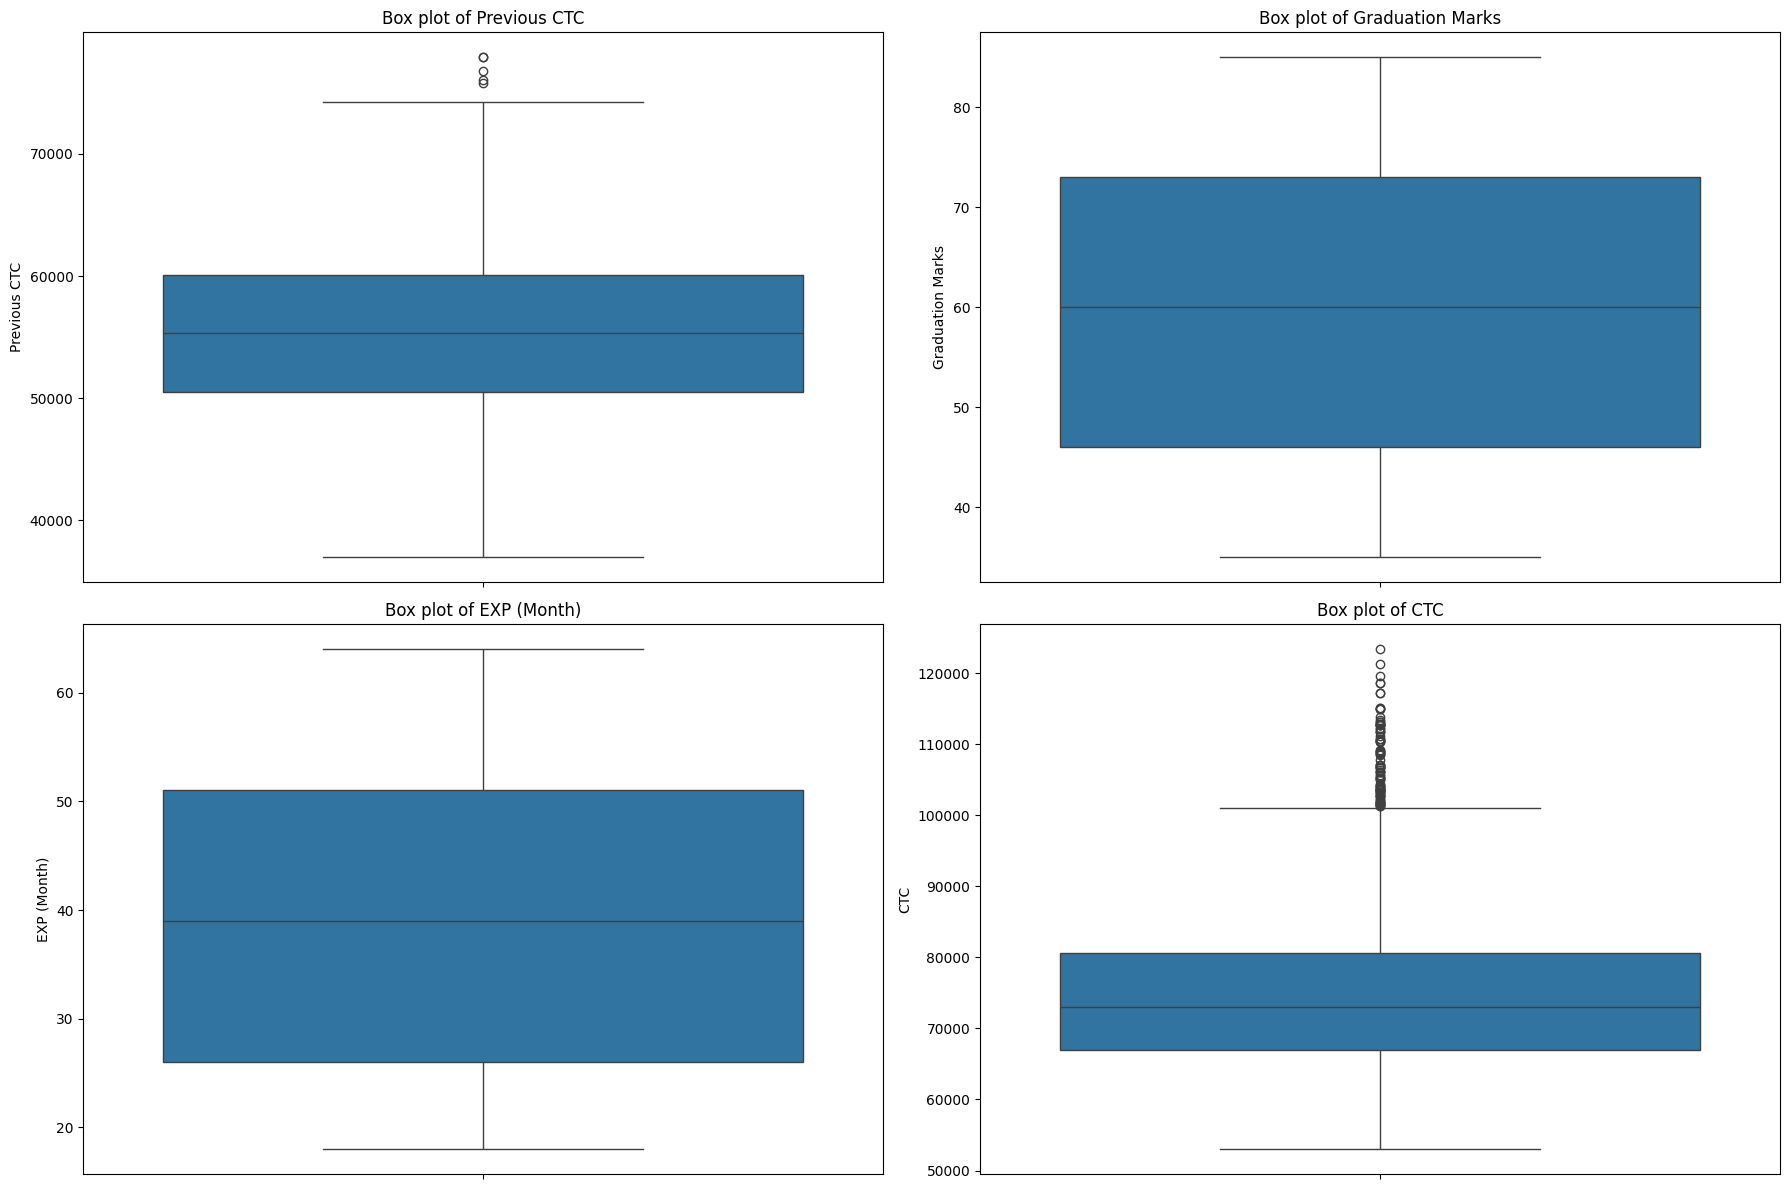

In [ ]:
# Creating Boxplots to visualize outliers

# Create subplots
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(18, 12))

# Flatten the axes array for easy iteration
axes = axes.flatten()

for i, column in enumerate(numeric_columns):
    sns.boxplot(y=df1[column], ax=axes[i])
    axes[i].set_title(f'Box plot of {column}')

plt.tight_layout()
plt.show()

In [ ]:
# Columns to check for outliers
columns_to_cap_floor = ['Previous CTC', 'CTC']

In [ ]:
# Handling outliers by capping and flooring Technique
for column in columns_to_cap_floor:
    lower_threshold = df1[column].quantile(0.01)
    upper_threshold = df1[column].quantile(0.99)
    df1[column] = df1[column].clip(lower=lower_threshold, upper=upper_threshold)

In [ ]:
# Copying data to ensure original data integrity
data = df1.copy()

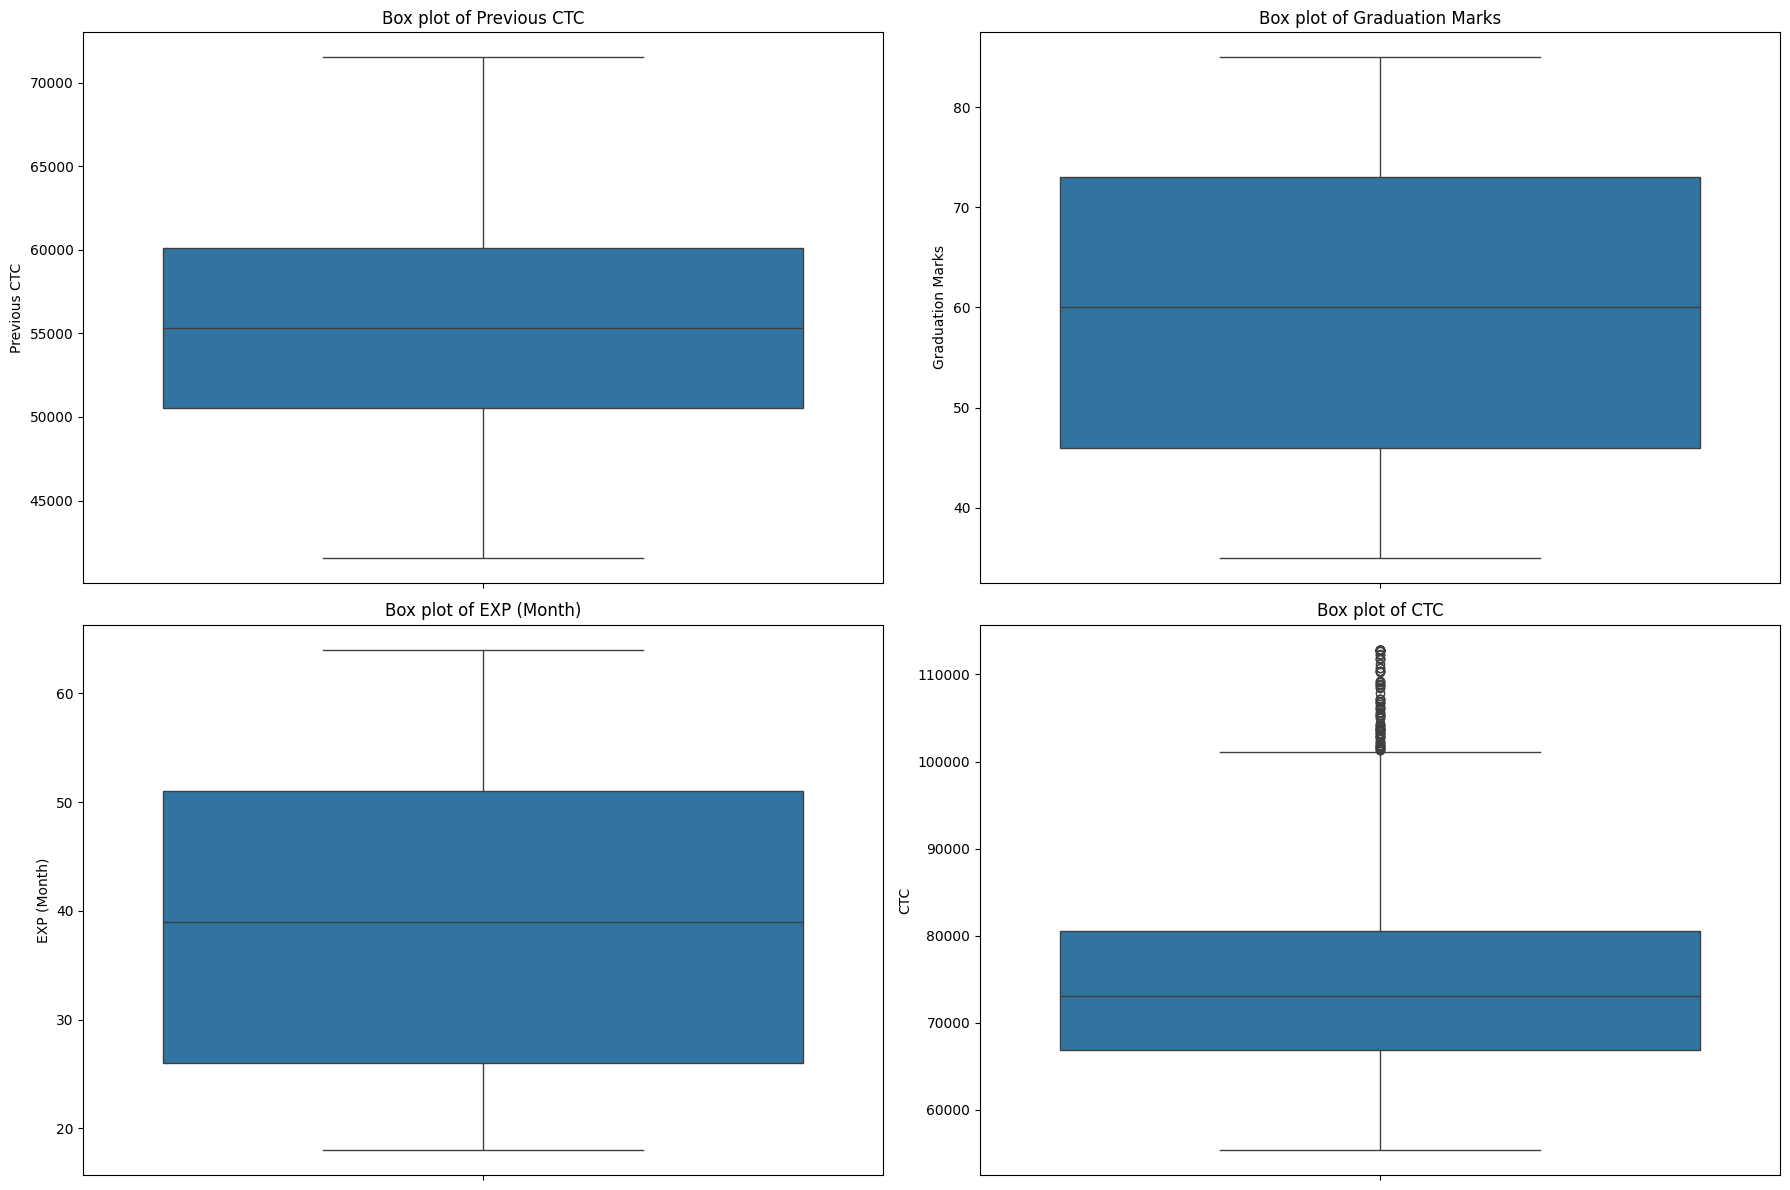

In [ ]:
# Replotting after handling outliers

# Create subplots
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(18, 12))

# Flatten the axes array for easy iteration
axes = axes.flatten()

# Plot each boxplot in a separate subplot
for i, column in enumerate(numeric_columns):
    sns.boxplot(y=data[column], ax=axes[i])
    axes[i].set_title(f'Box plot of {column}')

plt.tight_layout()
plt.show()

In [ ]:
# Describing the data to check the impact of capping and flooring
data.describe()

,College,City,Role,Previous CTC,Previous job change,Graduation Marks,EXP (Month),CTC,Experience_in_Years
count,1589.000000,1589.000000,1589.000000,1589.000000,1589.000000,1589.000000,1589.000000,1589.000000,1589.000000
mean,1.975456,0.485840,0.793581,55509.647854,2.528634,59.855255,39.044682,75329.422901,3.254248
std,0.838330,0.499957,0.404862,6547.642460,1.123918,14.935139,14.108875,12448.774732,1.172653
min,1.000000,0.000000,0.000000,41587.920000,1.000000,35.000000,18.000000,55386.704400,1.500000
25%,1.000000,0.000000,1.000000,50518.000000,2.000000,46.000000,26.000000,66902.350000,2.200000
50%,2.000000,0.000000,1.000000,55291.000000,3.000000,60.000000,39.000000,73028.670000,3.200000
75%,3.000000,1.000000,1.000000,60109.000000,4.000000,73.000000,51.000000,80588.670000,4.200000
max,3.000000,1.000000,1.000000,71506.920000,4.000000,85.000000,64.000000,112826.260000,5.300000


In [ ]:
# Confirming the shape of the data after processing
data.shape

(1589, 9)

# Exploratory Data Analysis

**Univariate Analysis**

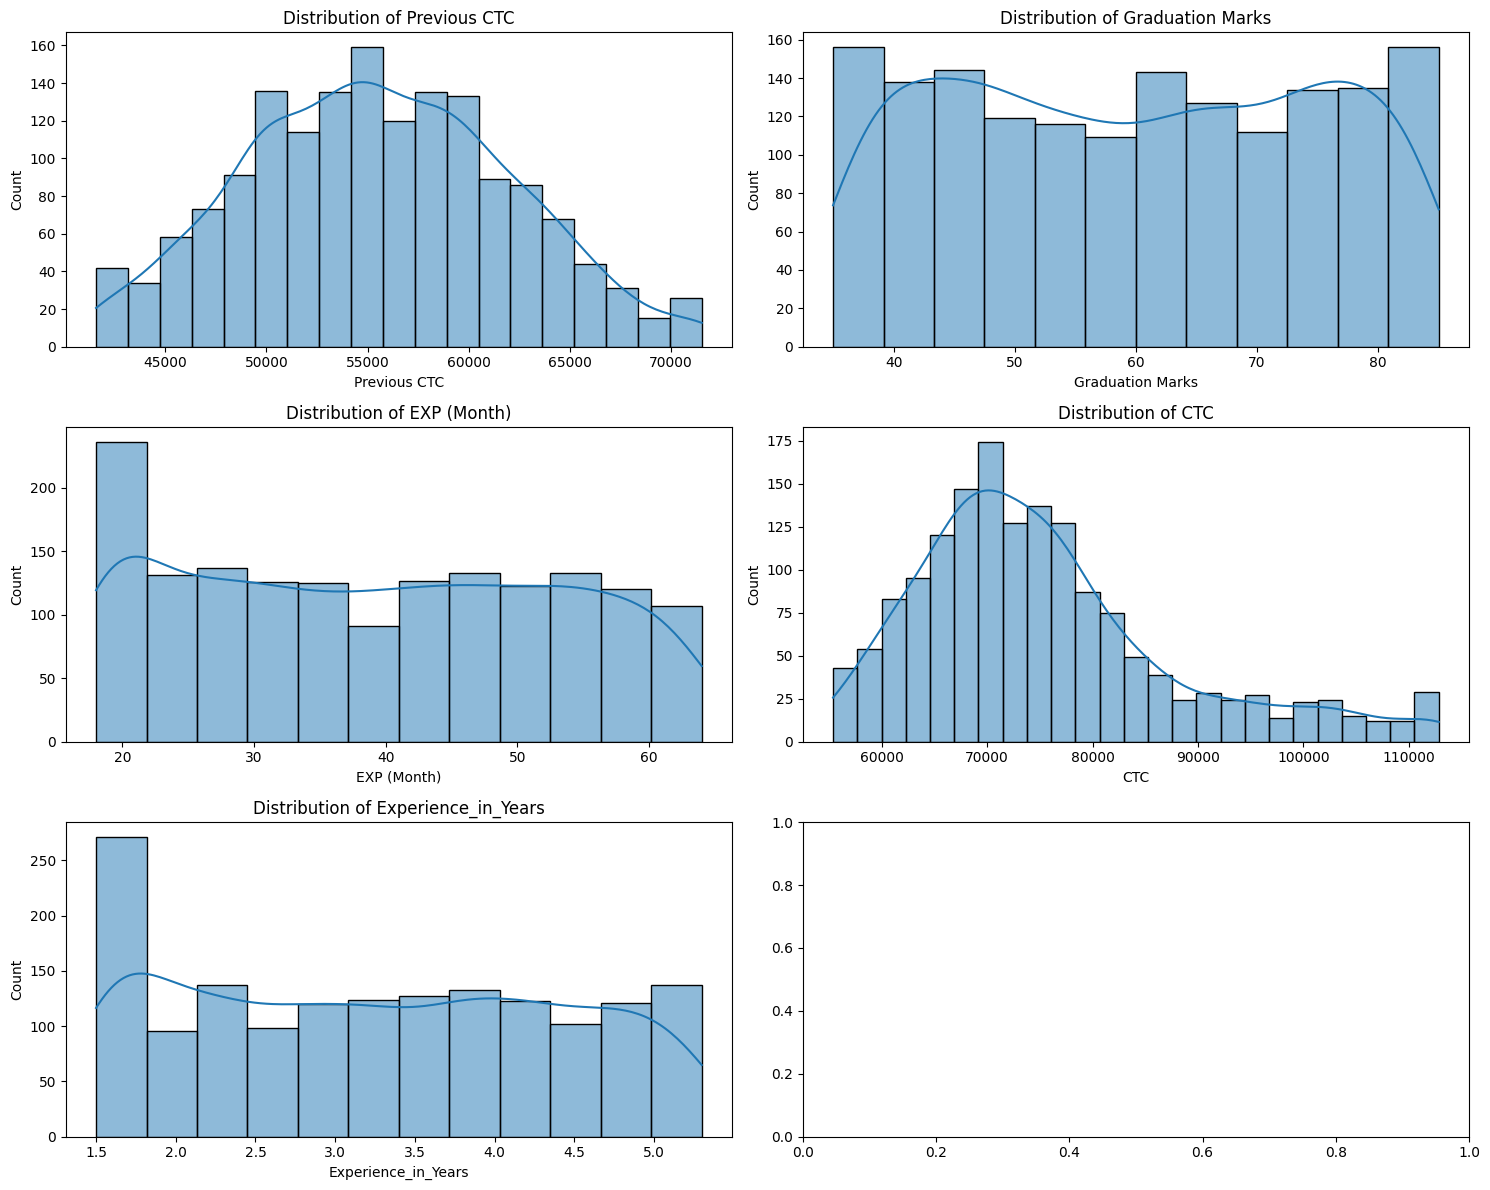

In [ ]:
# histograms to understand distributions

numeric_columns = ['Previous CTC', 'Graduation Marks', 'EXP (Month)', 'CTC', 'Experience_in_Years']

# Create subplots
fig, axs = plt.subplots(3, 2, figsize=(15, 12))

# Flatten the array of axes for easier iteration
axs = axs.flatten()

# Plot histograms on the subplots
for i, column in enumerate(numeric_columns):
    sns.histplot(data[column], kde=True, ax=axs[i])
    axs[i].set_title(f'Distribution of {column}')

plt.tight_layout()
plt.show()

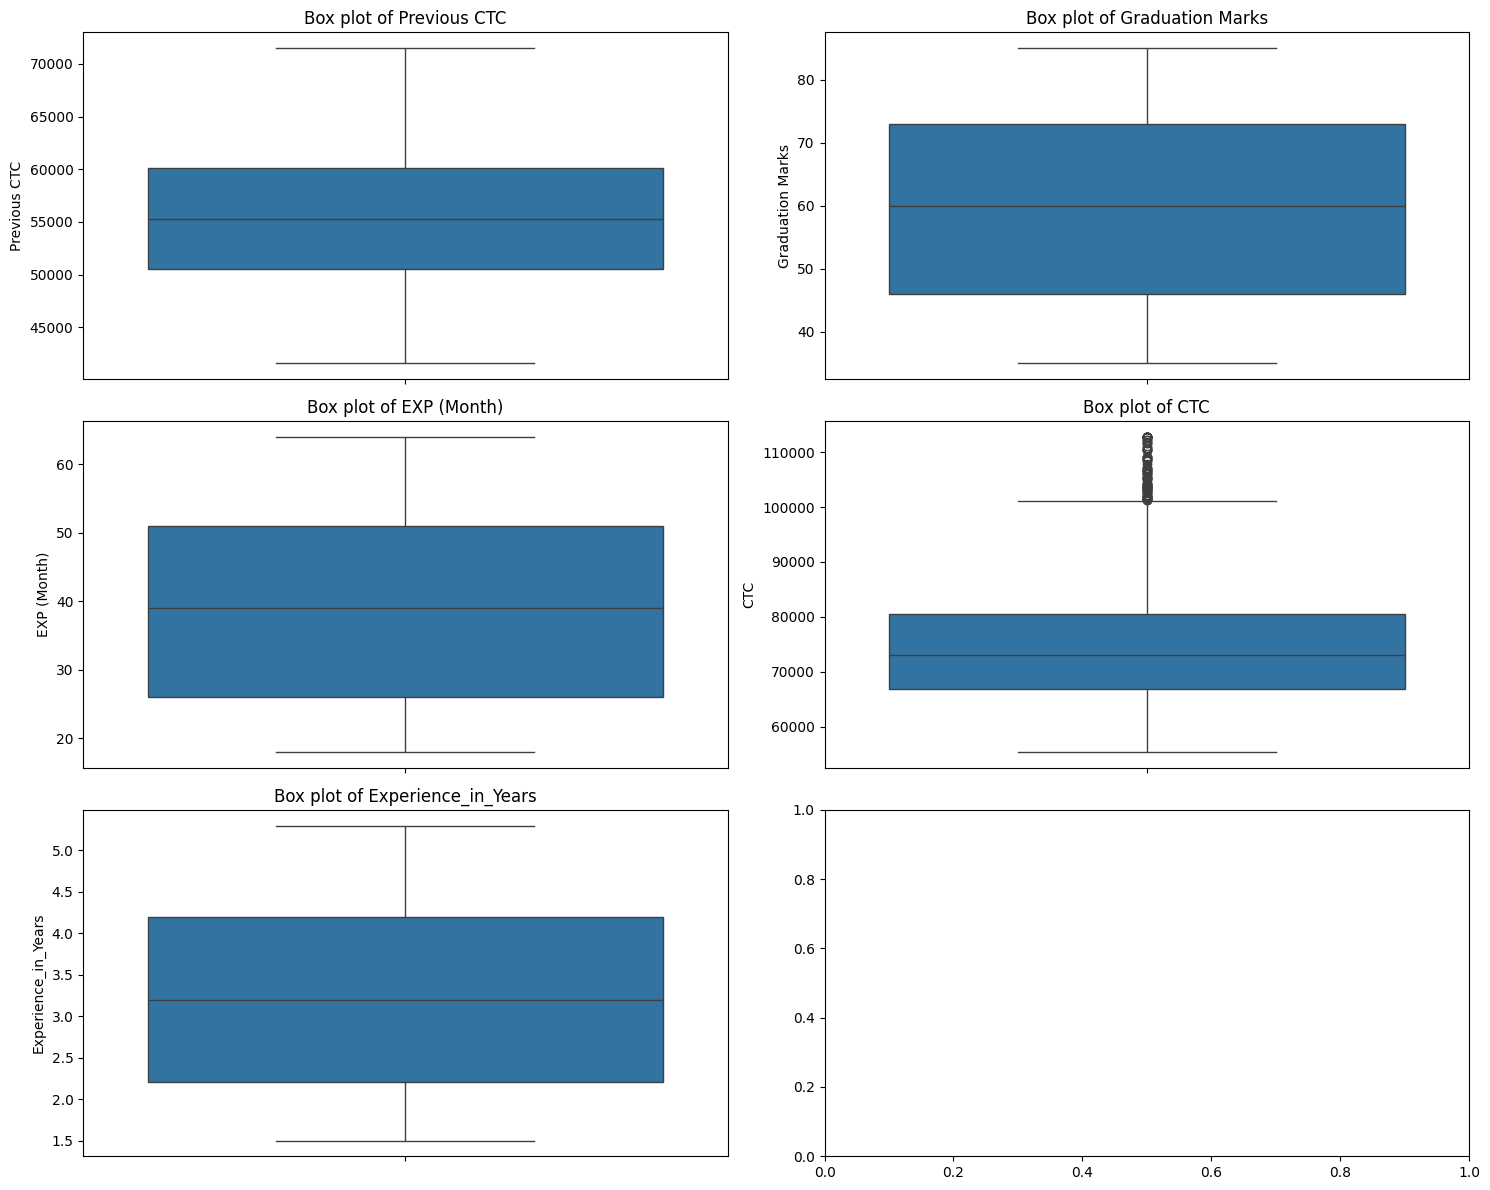

In [ ]:
# Box plots to further analyze the spread and presence of outliers
# Create subplots for box plots
fig, axs = plt.subplots(3, 2, figsize=(15, 12))
axs = axs.flatten()

for i, column in enumerate(numeric_columns):
    sns.boxplot(y=data[column], ax=axs[i])
    axs[i].set_title(f'Box plot of {column}')

plt.tight_layout()
plt.show()

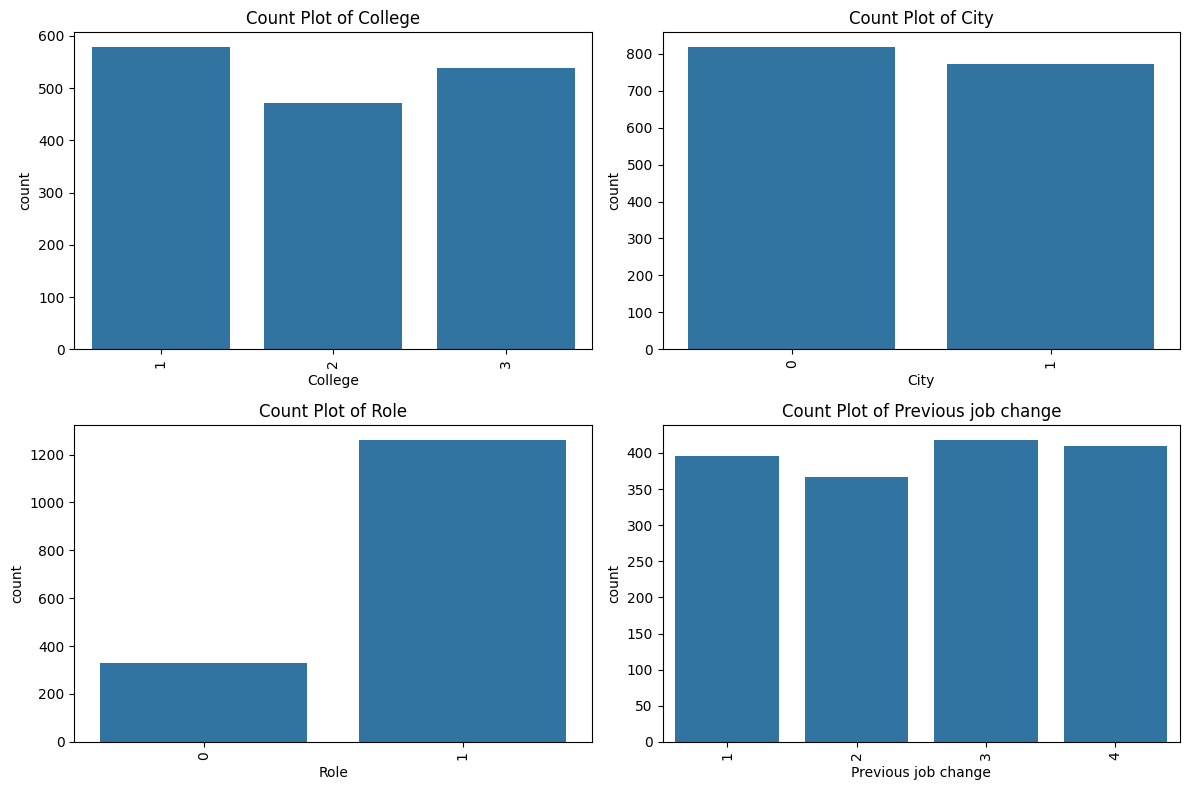

In [ ]:
# Creating the subplots
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# List of categorical columns
columns = ['College', 'City', 'Role','Previous job change']

# Flattening the axes array
axes = axes.flatten()

# Plotting count plots for each categorical column
for ax, column in zip(axes, columns):
    sns.countplot(x=data[column], ax=ax)
    ax.set_title(f'Count Plot of {column}')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=90)

plt.tight_layout()
plt.show()

# Bivariate Analysis

Bivariate analysis to explore relationships between features and target

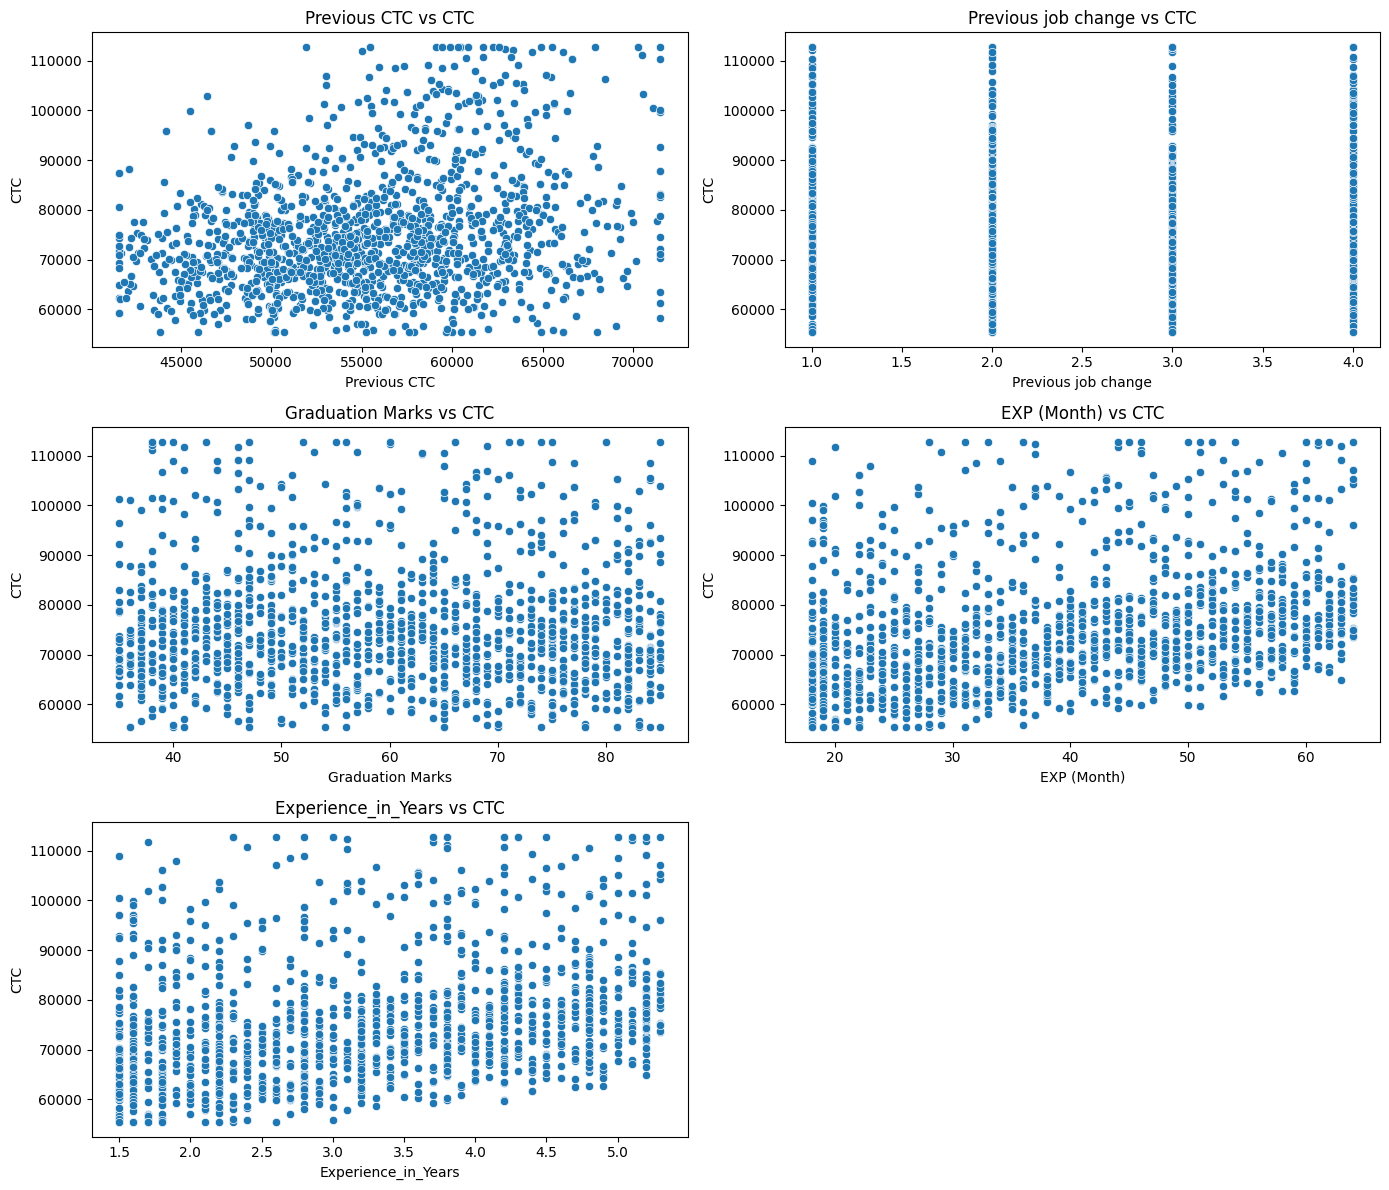

In [ ]:
# Numeric columns
columns_BA = ['Previous CTC','Previous job change', 'Graduation Marks', 'EXP (Month)','Experience_in_Years']

# Scatter plot for numeric columns
fig, axs = plt.subplots(3, 2, figsize=(14, 12))
axs = axs.flatten()

for i, column in enumerate(columns_BA):
    if column != 'CTC':
        sns.scatterplot(x=data[column], y=data['CTC'], ax=axs[i])
        axs[i].set_title(f'{column} vs CTC')
fig.delaxes(axs[-1])  # Remove the last empty subplot
plt.tight_layout()
plt.show()

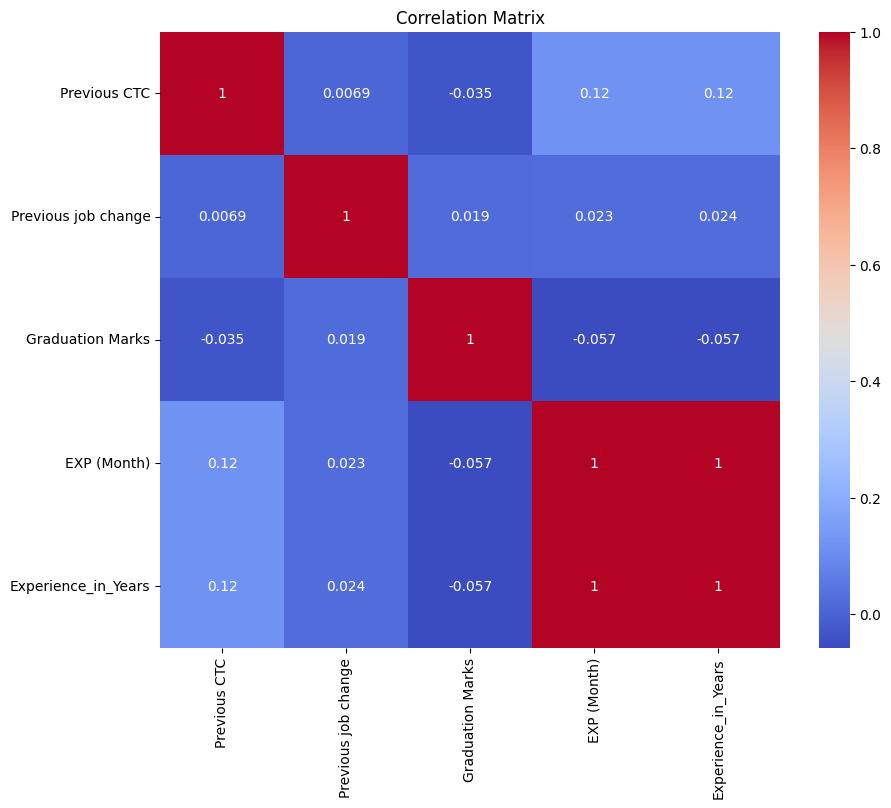

In [ ]:
# Displaying a correlation matrix to understand interdependencies

# Correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(data[columns_BA].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

# Multivariate Analysis

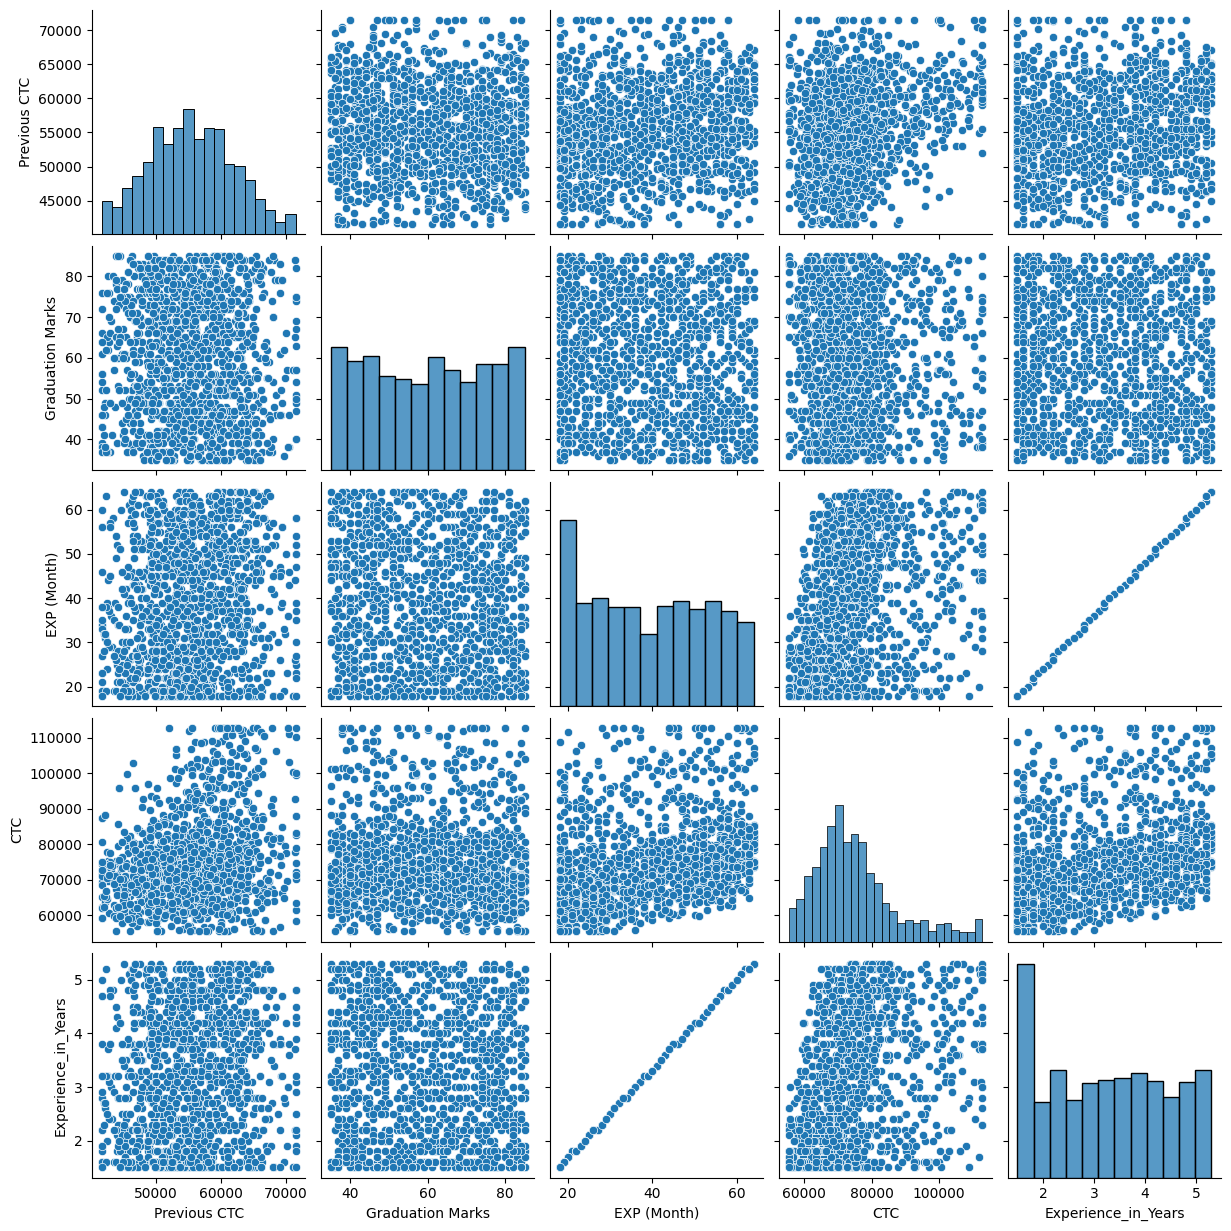

In [ ]:
# Pair plot for numeric columns
sns.pairplot(data[numeric_columns])
plt.show()

# Train Test Split

In [ ]:
# Splitting data into training and testing sets
X = data.drop('CTC', axis=1)
y = data['CTC']

In [ ]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=84)

In [ ]:
# Print the shapes of the datasets
print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

Shape of X_train: (1271, 8)
Shape of X_test: (318, 8)
Shape of y_train: (1271,)
Shape of y_test: (318,)


In [ ]:
X_train.columns

Index(['College', 'City', 'Role', 'Previous CTC', 'Previous job change',
       'Graduation Marks', 'EXP (Month)', 'Experience_in_Years'],
      dtype='object')

# Feature Scaling

In [ ]:
data.head(10)

,College,City,Role,Previous CTC,Previous job change,Graduation Marks,EXP (Month),CTC,Experience_in_Years
0,2,1,0,55523.0,3,66,19,71406.58,1.6
1,2,1,1,57081.0,1,84,18,68005.87,1.5
2,3,1,1,60347.0,2,52,28,76764.02,2.3
3,3,1,1,49010.0,2,81,33,82092.39,2.8
4,1,1,1,57879.0,4,74,32,73878.10,2.7
5,2,1,1,54340.0,4,73,31,59950.89,2.6
6,3,0,1,60298.0,1,42,46,66602.34,3.8
7,2,0,1,49944.0,2,56,37,57768.44,3.1
8,3,0,1,53124.0,4,40,37,70083.30,3.1
9,1,1,1,51141.0,1,47,60,85648.48,5.0


In [ ]:
# Renaming columns to reflect feature types
X_train.rename(columns={
    'College': 'College Tier'
}, inplace=True)

X_test.rename(columns={
    'College': 'College Tier'
}, inplace=True)

In [ ]:
X_train

,College Tier,City,Role,Previous CTC,Previous job change,Graduation Marks,EXP (Month),Experience_in_Years
579,3,1,1,44848.0,3,41,25,2.1
1012,2,0,1,60235.0,4,46,61,5.1
625,1,1,1,53160.0,1,46,29,2.4
1442,2,0,1,52300.0,4,52,34,2.8
981,2,1,1,49513.0,1,84,34,2.8
...,...,...,...,...,...,...,...,...
206,3,0,1,46791.0,3,59,59,4.9
1404,3,1,1,62919.0,3,42,61,5.1
501,1,0,1,46707.0,3,47,43,3.6
1336,1,0,1,53203.0,3,69,21,1.8


In [ ]:
# Initialize the scaler
scaler = StandardScaler()

In [ ]:
numeric_columns = ['Previous CTC', 'Previous job change' ,'Graduation Marks', 'EXP (Month)', 'Experience_in_Years']

In [ ]:
# Apply one-hot encoding to 'Previous job change' and 'College' columns
X_train = pd.get_dummies(X_train, columns=['College Tier']).astype(int)
X_test = pd.get_dummies(X_test, columns=['College Tier']).astype(int)

In [ ]:
# Scale the numeric columns
X_train_scaled = X_train.copy()
X_train_scaled[numeric_columns] = scaler.fit_transform(X_train[numeric_columns])

X_test_scaled = X_test.copy()
X_test_scaled[numeric_columns] = scaler.transform(X_test[numeric_columns])

In [ ]:
# Displaying transformed training data
X_train_scaled

,City,Role,Previous CTC,Previous job change,Graduation Marks,EXP (Month),Experience_in_Years,College Tier_1,College Tier_2,College Tier_3
579,1,1,-1.606157,0.420382,-1.256334,-0.988415,-0.627421,0,0,1
1012,0,1,0.728454,1.310892,-0.920914,1.560672,1.789101,0,1,0
625,1,1,-0.345009,-1.360637,-0.920914,-0.705183,-0.627421,1,0,0
1442,0,1,-0.475493,1.310892,-0.518410,-0.351143,-0.627421,0,1,0
981,1,1,-0.898354,-1.360637,1.628278,-0.351143,-0.627421,0,1,0
...,...,...,...,...,...,...,...,...,...,...
206,0,1,-1.311353,0.420382,-0.048822,1.419056,0.983593,0,0,1
1404,1,1,1.135688,0.420382,-1.189250,1.560672,1.789101,0,0,1
501,0,1,-1.324098,0.420382,-0.853830,0.286129,0.178086,1,0,0
1336,0,1,-0.338484,0.420382,0.622018,-1.271647,-1.432928,1,0,0


In [ ]:
y_train.head()

579     65897.67
1012    91425.96
625     62498.78
1442    66657.86
981     69525.33
Name: CTC, dtype: float64

# Model Building and Evaluation

In [ ]:
# Initialize a dictionary to hold model performance metrics
model_metrics_dict = {
    'Model Name': [],
    'Training MSE': [],
    'Testing MSE': [],
    'Training R2 Score': [],
    'Testing R2 Score': []
}

# Function to add model metrics to the dictionary
def add_model_metrics(name, train_mse, test_mse, train_r2, test_r2):
    model_metrics_dict['Model Name'].append(name)
    model_metrics_dict['Training MSE'].append(train_mse)
    model_metrics_dict['Testing MSE'].append(test_mse)
    model_metrics_dict['Training R2 Score'].append(train_r2)
    model_metrics_dict['Testing R2 Score'].append(test_r2)

In [ ]:
# 1. Linear Regression
# Training the Linear Regression model
linear_model = LinearRegression()
linear_model.fit(X_train_scaled, y_train)

# Making predictions on the training and testing sets
train_preds = linear_model.predict(X_train_scaled)
test_preds = linear_model.predict(X_test_scaled)

# Calculating MSE and R2 scores for both training and testing sets
train_mse = mean_squared_error(y_train, train_preds)
train_r2 = r2_score(y_train, train_preds)
test_mse = mean_squared_error(y_test, test_preds)
test_r2 = r2_score(y_test, test_preds)

# Printing the evaluation metrics
print(f'Linear Regression Training - MSE: {train_mse}, R2: {train_r2}')
print(f'Linear Regression Testing - MSE: {test_mse}, R2: {test_r2}')


Linear Regression Training - MSE: 72126422.13293111, R2: 0.5383403894831481
Linear Regression Testing - MSE: 71476624.24328932, R2: 0.5216801997843092


In [ ]:
# Add metrics for Linear Regression
add_model_metrics(
    'Linear Regression',train_mse, test_mse, train_r2, test_r2
)

In [ ]:
# 2. Lasso Regression
# Define the model
lasso = Lasso()

# Define the parameter grid
param_grid = {'alpha': [0.001, 0.01, 0.1, 1.0, 10.0]}

# Set up the GridSearchCV
grid_search = GridSearchCV(estimator=lasso, param_grid=param_grid, cv=5, scoring='r2', n_jobs=-1)

# Fit GridSearchCV
grid_search.fit(X_train_scaled, y_train)

# Get the best model
best_lasso = grid_search.best_estimator_
best_params = grid_search.best_params_

# Make predictions
preds_train = best_lasso.predict(X_train_scaled)
preds_test = best_lasso.predict(X_test_scaled)

# Calculate MSE and R2
train_mse_lasso = mean_squared_error(y_train, preds_train)
train_r2_lasso = r2_score(y_train, preds_train)
test_mse_lasso = mean_squared_error(y_test, preds_test)
test_r2_lasso = r2_score(y_test, preds_test)

# Print results
print("Best Lasso Regression Parameters:", best_params)
print(f"Training MSE: {train_mse_lasso}, R2: {train_r2_lasso}")
print(f"Testing MSE: {test_mse_lasso}, R2: {test_r2_lasso}")

Best Lasso Regression Parameters: {'alpha': 10.0}
Training MSE: 72128517.2696811, R2: 0.5383269791407608
Testing MSE: 71395188.1851953, R2: 0.5222251678693337


In [ ]:
# Add metrics for Lasso Regression
add_model_metrics(
    'Lasso Regression',train_mse_lasso, test_mse_lasso, train_r2_lasso, test_r2_lasso
)

In [ ]:
# 3. Ridge Regression
# Define the model
ridge = Ridge()

# Define the parameter grid for alpha values
param_grid = {
    'alpha': [0.001, 0.01, 0.1, 1.0, 10.0]
}

# Initialize the GridSearchCV object with cross-validation
grid_search_ridge = GridSearchCV(estimator=ridge, param_grid=param_grid, cv=5, scoring='r2', n_jobs=-1)

# Fit GridSearchCV to the scaled training data
grid_search_ridge.fit(X_train_scaled, y_train)

# Get the best estimator and its parameters
best_ridge_model = grid_search_ridge.best_estimator_
best_params = grid_search_ridge.best_params_

# Predictions on training and testing sets
train_preds_ridge = best_ridge_model.predict(X_train_scaled)
test_preds_ridge = best_ridge_model.predict(X_test_scaled)

# Calculate MSE and R2 for both training and testing sets
train_mse_ridge = mean_squared_error(y_train, train_preds_ridge)
train_r2_ridge = r2_score(y_train, train_preds_ridge)
test_mse_ridge = mean_squared_error(y_test, test_preds_ridge)
test_r2_ridge = r2_score(y_test, test_preds_ridge)

# Print the best model's parameters and its performance metrics
print("Best Ridge Regression Parameters:", best_params)
print(f"Training MSE: {train_mse_ridge}, R2: {train_r2_ridge}")
print(f"Testing MSE: {test_mse_ridge}, R2: {test_r2_ridge}")


Best Ridge Regression Parameters: {'alpha': 1.0}
Training MSE: 72127944.57353717, R2: 0.538330644797131
Testing MSE: 71522972.0976872, R2: 0.5213700410899007


In [ ]:
# Add metrics for Ridge Regression
add_model_metrics(
    'Ridge Regression',train_mse_ridge, test_mse_ridge, train_r2_ridge, test_r2_ridge
)

In [ ]:
# 4. Elasticnet Regression
# Define the ElasticNet model
elasticnet = ElasticNet()

# Define the parameter grid
elasticnet_param_grid = {
    'alpha': [0.001, 0.01, 0.1, 1.0, 10.0],
    'l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9]
}

# Initialize GridSearchCV
grid_search_elasticnet = GridSearchCV(
    estimator=elasticnet,
    param_grid=elasticnet_param_grid,
    scoring='r2',
    cv=5,
    n_jobs=-1
)

# Fit GridSearchCV to the scaled training data
grid_search_elasticnet.fit(X_train_scaled, y_train)

# Get the best estimator and its parameters
best_elasticnet = grid_search_elasticnet.best_estimator_
best_params = grid_search_elasticnet.best_params_

# Predictions on training and testing sets using the best model
train_preds_elasticnet = best_elasticnet.predict(X_train_scaled)
test_preds_elasticnet = best_elasticnet.predict(X_test_scaled)

# Calculate MSE and R2 for both training and testing sets
train_mse_elasticnet = mean_squared_error(y_train, train_preds_elasticnet)
train_r2_elasticnet = r2_score(y_train, train_preds_elasticnet)
test_mse_elasticnet = mean_squared_error(y_test, test_preds_elasticnet)
test_r2_elasticnet = r2_score(y_test, test_preds_elasticnet)

# Print the best model's parameters and its performance metrics
print("Best ElasticNet Regression Parameters:", best_params)
print(f"Training MSE: {train_mse_elasticnet}, R2: {train_r2_elasticnet}")
print(f"Testing MSE: {test_mse_elasticnet}, R2: {test_r2_elasticnet}")

Best ElasticNet Regression Parameters: {'alpha': 0.01, 'l1_ratio': 0.7}
Training MSE: 72147726.26358783, R2: 0.5382040281280367
Testing MSE: 71662217.48788649, R2: 0.5204382143853494


In [ ]:
# Add metrics for ElasticNet Regression
add_model_metrics(
    'ElasticNet Regression',train_mse_elasticnet, test_mse_elasticnet, train_r2_elasticnet, test_r2_elasticnet
)

In [ ]:
# 5. Polynomial Regression
# Create a pipeline that first transforms data using PolynomialFeatures then applies LinearRegression
pipeline = make_pipeline(PolynomialFeatures(), LinearRegression())

# Define the parameter grid to search over
param_grid = {
    'polynomialfeatures__degree': [1, 2, 3, 4, 5]  # Testing polynomial degrees from 1 to 5
}

# Initialize GridSearchCV with the pipeline and the parameter grid
grid_search_poly = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    scoring='r2',
    cv=5,
    n_jobs=-1
)

# Fit GridSearchCV to the scaled training data
grid_search_poly.fit(X_train_scaled, y_train)

# Get the best estimator and its parameters
best_poly_model = grid_search_poly.best_estimator_
best_params = grid_search_poly.best_params_

# Predictions on training and testing sets using the best model
train_preds_poly = best_poly_model.predict(X_train_scaled)
test_preds_poly = best_poly_model.predict(X_test_scaled)

# Calculate MSE and R2 for both training and testing sets
train_mse_poly = mean_squared_error(y_train, train_preds_poly)
train_r2_poly = r2_score(y_train, train_preds_poly)
test_mse_poly = mean_squared_error(y_test, test_preds_poly)
test_r2_poly = r2_score(y_test, test_preds_poly)

# Print the best model's parameters and its performance metrics
print("Best Polynomial Regression Parameters:", best_params)
print(f"Training MSE: {train_mse_poly}, R2: {train_r2_poly}")
print(f"Testing MSE: {test_mse_poly}, R2: {test_r2_poly}")

Best Polynomial Regression Parameters: {'polynomialfeatures__degree': 2}
Training MSE: 57803514.59134838, R2: 0.6300170278297624
Testing MSE: 61112038.00799647, R2: 0.5910397543221555


In [ ]:
# Add metrics for Polynomial Regression
add_model_metrics(
    'Polynomial Regression',train_mse_poly, test_mse_poly, train_r2_poly, test_r2_poly
)

In [ ]:
# 6.Decision Tree Regression

# Define the parameter grid for Decision Tree
param_grid = {
    'max_depth': [None, 10, 20, 30, 50],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['auto', 'sqrt', 'log2']
}

# Initialize Decision Tree Regressor
dt_reg = DecisionTreeRegressor(random_state=42)

# Perform Grid Search to find the best parameters
grid_search = GridSearchCV(dt_reg, param_grid, cv=5, scoring='r2', n_jobs=-1)
grid_search.fit(X_train_scaled, y_train)

# Get the best model from grid search
best_model = grid_search.best_estimator_

# Predictions and Evaluation
y_pred_train = best_model.predict(X_train_scaled)
y_pred_test = best_model.predict(X_test_scaled)

# Calculate MSE and R2 scores for training set
train_mse_dt = mean_squared_error(y_train, y_pred_train)
train_r2_dt = r2_score(y_train, y_pred_train)

# Calculate MSE and R2 scores for testing set
test_mse_dt = mean_squared_error(y_test, y_pred_test)
test_r2_dt = r2_score(y_test, y_pred_test)

# Print results
print(f'Best Decision Tree Regression Training - MSE: {train_mse_dt}, R2: {train_r2_dt}')
print(f'Best Decision Tree Regression Testing - MSE: {test_mse_dt}, R2: {test_r2_dt}')
print(f'Best parameters found: {grid_search.best_params_}')


Best Decision Tree Regression Training - MSE: 31267620.098470595, R2: 0.7998653352048338
Best Decision Tree Regression Testing - MSE: 79597999.01393506, R2: 0.46733216084293827
Best parameters found: {'max_depth': 10, 'max_features': 'auto', 'min_samples_leaf': 4, 'min_samples_split': 10}


In [ ]:
# Add metrics for Decision Tree Regression
add_model_metrics(
    'Decision Tree Regression',train_mse_dt, test_mse_dt, train_r2_dt, test_r2_dt
)

In [ ]:
# 7. Random Forest Regression
# Define the RandomForestRegressor
forest_model = RandomForestRegressor(random_state=42)

# Define the parameter grid
params = {
    'n_estimators': [50, 100, 150],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Perform Grid Search with cross-validation
grid_search = GridSearchCV(estimator=forest_model, param_grid=params, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)
grid_search.fit(X_train_scaled, y_train)

# Get the best model and its parameters
best_forest = grid_search.best_estimator_
best_forest_params = grid_search.best_params_

print("Best Parameters for Random Forest Regression:")
print(best_forest_params)

# Predictions and Evaluation using the best model
train_preds_forest = best_forest.predict(X_train_scaled)
test_preds_forest = best_forest.predict(X_test_scaled)

train_mse_forest = mean_squared_error(y_train, train_preds_forest)
train_r2_forest = r2_score(y_train, train_preds_forest)
test_mse_forest = mean_squared_error(y_test, test_preds_forest)
test_r2_forest = r2_score(y_test, test_preds_forest)

print(f'Random Forest Regression Training - MSE: {train_mse_forest}, R2: {train_r2_forest}')
print(f'Random Forest Regression Testing - MSE: {test_mse_forest}, R2: {test_r2_forest}')


Best Parameters for Random Forest Regression:
{'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
Random Forest Regression Training - MSE: 18304757.461527612, R2: 0.8828367337462042
Random Forest Regression Testing - MSE: 57029148.844920054, R2: 0.6183623475400197


In [ ]:
# Add metrics for Random Forest Regression
add_model_metrics(
    'Random Forest Regression',train_mse_forest, test_mse_forest, train_r2_forest, test_r2_forest
)

In [ ]:
# 8. Gradient Boosting Regression

# Define the GradientBoostingRegressor
gb_model = GradientBoostingRegressor(random_state=42)

# Define the parameter grid
gb_params = {
    'n_estimators': [50, 100, 150],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5, 7],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Perform Grid Search with cross-validation
gb_grid_search = GridSearchCV(estimator=gb_model, param_grid=gb_params, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)
gb_grid_search.fit(X_train_scaled, y_train)

# Get the best model and its parameters
best_gb = gb_grid_search.best_estimator_
best_gb_params = gb_grid_search.best_params_

print("Best Parameters for Gradient Boosting Regression:")
print(best_gb_params)

# Predictions and Evaluation using the best model
train_preds_gb = best_gb.predict(X_train_scaled)
test_preds_gb = best_gb.predict(X_test_scaled)

train_mse_gb = mean_squared_error(y_train, train_preds_gb)
train_r2_gb = r2_score(y_train, train_preds_gb)
test_mse_gb = mean_squared_error(y_test, test_preds_gb)
test_r2_gb = r2_score(y_test, test_preds_gb)

print(f'Gradient Boosting Regression Training - MSE: {train_mse_gb}, R2: {train_r2_gb}')
print(f'Gradient Boosting Regression Testing - MSE: {test_mse_gb}, R2: {test_r2_gb}')


Best Parameters for Gradient Boosting Regression:
{'learning_rate': 0.1, 'max_depth': 3, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 100}
Gradient Boosting Regression Training - MSE: 42420595.79523103, R2: 0.7284784805126545
Gradient Boosting Regression Testing - MSE: 59383296.65464916, R2: 0.6026084486682


In [ ]:
# Add metrics for Gradient Boosting Regression
add_model_metrics(
  'Gradient Boosting Regression',train_mse_gb, test_mse_gb, train_r2_gb, test_r2_gb
)

In [ ]:
# 9. AdaBoost Regression

# Define the AdaBoostRegressor
ada_model = AdaBoostRegressor(random_state=42)

# Define the parameter grid for AdaBoost
ada_params = {
    'n_estimators': [50, 100, 150],
    'learning_rate': [0.01, 0.05, 0.1, 0.5, 1.0],
    'loss': ['linear', 'square', 'exponential']
}

# Perform Grid Search with cross-validation
ada_grid_search = GridSearchCV(estimator=ada_model, param_grid=ada_params, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)
ada_grid_search.fit(X_train_scaled, y_train)

# Get the best AdaBoost model and its parameters
best_ada = ada_grid_search.best_estimator_
best_ada_params = ada_grid_search.best_params_

print("Best Parameters for AdaBoost Regression:")
print(best_ada_params)

# Predictions and Evaluation using the best AdaBoost model
train_preds_ada = best_ada.predict(X_train_scaled)
test_preds_ada = best_ada.predict(X_test_scaled)

train_mse_ada = mean_squared_error(y_train, train_preds_ada)
train_r2_ada = r2_score(y_train, train_preds_ada)
test_mse_ada = mean_squared_error(y_test, test_preds_ada)
test_r2_ada = r2_score(y_test, test_preds_ada)

print(f'AdaBoost Regression Training - MSE: {train_mse_ada}, R2: {train_r2_ada}')
print(f'AdaBoost Regression Testing - MSE: {test_mse_ada}, R2: {test_r2_ada}')

Best Parameters for AdaBoost Regression:
{'learning_rate': 0.01, 'loss': 'linear', 'n_estimators': 150}
AdaBoost Regression Training - MSE: 58239501.698921055, R2: 0.6272264050271865
AdaBoost Regression Testing - MSE: 58399577.72910633, R2: 0.6091914713684952


In [ ]:
# Add metrics for AdaBoost Regression
add_model_metrics(
    'AdaBoost Regression',train_mse_ada, test_mse_ada, train_r2_ada, test_r2_ada
)

In [ ]:
# 10. XGBoost Regression

# Define the XGBoost Regressor
xgb_model = xgb.XGBRegressor(random_state=42)

# Define the parameter grid for XGBoost
xgb_params = {
    'n_estimators': [50, 100, 150],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5, 7],
    'min_child_weight': [1, 3, 5],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0],
    'gamma': [0, 0.1, 0.3]
}

# Perform Grid Search with cross-validation
xgb_grid_search = GridSearchCV(estimator=xgb_model, param_grid=xgb_params, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)
xgb_grid_search.fit(X_train_scaled, y_train)

# Get the best XGBoost model and its parameters
best_xgb = xgb_grid_search.best_estimator_
best_xgb_params = xgb_grid_search.best_params_

print("Best Parameters for XGBoost Regression:")
print(best_xgb_params)

# Predictions and Evaluation using the best XGBoost model
train_preds_xgb = best_xgb.predict(X_train_scaled)
test_preds_xgb = best_xgb.predict(X_test_scaled)

train_mse_xgb = mean_squared_error(y_train, train_preds_xgb)
train_r2_xgb = r2_score(y_train, train_preds_xgb)
test_mse_xgb = mean_squared_error(y_test, test_preds_xgb)
test_r2_xgb = r2_score(y_test, test_preds_xgb)

print(f'XGBoost Regression Training - MSE: {train_mse_xgb}, R2: {train_r2_xgb}')
print(f'XGBoost Regression Testing - MSE: {test_mse_xgb}, R2: {test_r2_xgb}')

Best Parameters for XGBoost Regression:
{'colsample_bytree': 0.8, 'gamma': 0, 'learning_rate': 0.05, 'max_depth': 5, 'min_child_weight': 1, 'n_estimators': 100, 'subsample': 0.8}
XGBoost Regression Training - MSE: 32093844.260666102, R2: 0.7945769219765193
XGBoost Regression Testing - MSE: 61287316.92204613, R2: 0.5898667921679148


In [ ]:
# Add metrics for XGBoost Regression
add_model_metrics(
    'Random Forest Regression',train_mse_xgb, test_mse_xgb, train_r2_xgb, test_r2_xgb
)

In [ ]:
# Convert the dictionary to a DataFrame
pd_final = pd.DataFrame(model_metrics_dict)

In [ ]:
pd_final

,Model Name,Training MSE,Testing MSE,Training R2 Score,Testing R2 Score
0,Linear Regression,7.212642e+07,7.147662e+07,0.538340,0.521680
1,Lasso Regression,7.212852e+07,7.139519e+07,0.538327,0.522225
2,Ridge Regression,7.212794e+07,7.152297e+07,0.538331,0.521370
3,ElasticNet Regression,7.214773e+07,7.166222e+07,0.538204,0.520438
4,Polynomial Regression,5.780351e+07,6.111204e+07,0.630017,0.591040
5,Decision Tree Regression,3.126762e+07,7.959800e+07,0.799865,0.467332
6,Random Forest Regression,1.830476e+07,5.702915e+07,0.882837,0.618362
7,Gradient Boosting Regression,4.242060e+07,5.938330e+07,0.728478,0.602608
8,AdaBoost Regression,5.823950e+07,5.839958e+07,0.627226,0.609191
9,Random Forest Regression,3.209384e+07,6.128732e+07,0.794577,0.589867


# **The Random Forest Regressor performs good on this dataset compared to other algorithms, achieving an R2 score of 0.617202. This indicates that the model explains approximately 61.72% of the variability in the target variable**

In [ ]:
# Collecting input data from the user
city = int(input("Enter City (0 for Metro, 1 for Non-Metro): "))
role = int(input("Enter Role (0 for Manager, 1 for Executive): "))
previous_ctc = float(input("Enter Previous CTC: "))
previous_job_change = int(input("Enter number of Previous Job Changes: "))
graduation_marks = float(input("Enter Graduation Marks (as a percentage): "))
exp_month = float(input("Enter Experience in Months: "))
experience_in_years = exp_month / 12  # Calculate years from months

# Collecting input data from the user for the college tier
college_tier_input = int(input("Enter the College Tier (1 for Tier 1, 2 for Tier 2, 3 for Tier 3): "))

# Initialize all college tier inputs to 0
college_tier_1, college_tier_2, college_tier_3 = 0, 0, 0

# Set the appropriate college tier based on user input
if college_tier_input == 1:
    college_tier_1 = 1
elif college_tier_input == 2:
    college_tier_2 = 1
elif college_tier_input == 3:
    college_tier_3 = 1

print("College Tier 1:", college_tier_1)
print("College Tier 2:", college_tier_2)
print("College Tier 3:", college_tier_3)

# Preparing the features that need scaling
features_to_scale = np.array([previous_ctc, previous_job_change, graduation_marks, exp_month, experience_in_years]).reshape(1, -1)

# Scaling the specified features
features_scaled = scaler.transform(features_to_scale)

# Creating a complete array for the input variables including both scaled and categorical features
input_features = np.hstack((features_scaled, [[city, role, college_tier_1, college_tier_2, college_tier_3]]))

# Assuming 'best_forest' is your trained RandomForestRegressor
predicted_ctc = best_forest.predict(input_features)
print(f'Predicted CTC for the given inputs: {predicted_ctc[0]}')

Enter City (0 for Metro, 1 for Non-Metro): 0
Enter Role (0 for Manager, 1 for Executive): 1
Enter Previous CTC: 60235
Enter number of Previous Job Changes: 4
Enter Graduation Marks (as a percentage): 46
Enter Experience in Months: 61
Enter the College Tier (1 for Tier 1, 2 for Tier 2, 3 for Tier 3): 2
College Tier 1: 0
College Tier 2: 1
College Tier 3: 0
Predicted CTC for the given inputs: 71560.02629260065


# **1. Your views about the problem statement?**

The problem statement effectively addresses the challenge of setting fair salaries for new hires at TechWorks Consulting. By using machine learning to base salary offers on data such as college tier, city type, role, and experience, the company can ensure competitive and unbiased compensation. This approach not only enhances employee satisfaction but also reduces human error and bias, making it a valuable tool for strategic hiring and retention in a tech-driven environment.

# **2. What will be your approach to solving this task?**

My approach will involve several key steps:

* Data Exploration: Understanding the dataset through statistical summaries, distribution checks, and identifying relationships among features.
* Data Cleaning: Handling missing values, outliers, and incorrect data entries to refine the dataset for better model performance.
* Data Visualization
* Exploratory Data Analysis
* Feature Engineering: Converting categorical variables into numerical format, and creating new features that may help in improving the model's prediction capability, such as deriving insights from existing data.
* Model Selection: Evaluating different regression models to see which performs best given the data. This would involve splitting the data into training and testing sets to validate the model's performance.
* Model Training and Optimization: Using cross-validation and hyperparameter tuning to refine the model and improve accuracy.
* Evaluation: Comparing different models based on metrics like MSE, R2 Score to select the best performer.




# 3. What were the available ML model options you had to perform this task?

For the regression task, I considered several models:

* Linear Regression: A good baseline model for regression tasks.
* Ridge Regression and Lasso Regression: These include regularization parameters that can help prevent overfitting.
* ElasticNet Regression: Combines the properties of both Ridge and Lasso regression.
* Decision Tree Regressor and Random Forest Regressor: Non-linear models that can capture complex relationships between features.
* Gradient Boosting Machines (GBM) and XGBoost: Powerful ensemble methods that provide highly accurate results.
* AdaBoost Regressor: Another ensemble method that can increase the performance of decision trees.

After evaluating all models, the one with the highest R2 score will be selected for final use. This approach ensures that the chosen model offers the best performance in terms of explaining the variance in the dataset and predicting new data.



# **4. Which model’s performance is best and what could be the possible reason for that?**


After testing different models, the Random Forest model performed the best, achieving the highest R2 score of 0.618362. This suggests that it's really good at predicting the salaries based on the given data, likely because it handles the complex relationships between different factors well.

# **5. What steps can you take to improve this selected model’s performance even further?**

To further enhance the model's performance, the I consider following strategies:

* Advanced Feature Engineering: More complex conversions and mutual effects of the attributes could be further investigated.

* Ensemble Techniques: Training with several models or apply stacking/blending methods in order to minimize the variance and the bias.

* Adding More Data: It is sometimes possible if the resources permit to expand the size of the database to have more training samples which would positively affect the performance of the model in a model that is known to be very data – intensive such as the Random Forest.

* Feature Selection: Employ the feature importance scores from the Random Forest model to select relevant features that have a high effect on the prediction and this could be helpful in preventing overfitting of the model.